This is a cleaner version of the experimental pipeline. The reason behind the creation of this new file is due to the lack of comprehensivness of the experimental pipeline. this is due to the sheer amount of code cells as well as text which has made the comprehension level of the pipeline reduce, as you do not know what is truly needed and what was used as to debug.
this file is meant to help with the problems previosuly stated as well as to update the previous versions of the pipeline, as those had only counted up to phase 1

## GitHub & Environment Setup

## Clone & checkout

In [1]:
REPO_URL = "https://github.com/Log-Yair/Endymion.git"
REPO_DIR = "/content/Endymion"
BRANCH = "phase2-ml-illum"

import os, sys

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}

%cd {REPO_DIR}
!git checkout {BRANCH}
!git pull


Cloning into '/content/Endymion'...
remote: Enumerating objects: 760, done.
remote: Counting objects: 100% (236/236), done.
remote: Compressing objects: 100% (118/118), done.
remote: Total 760 (delta 174), reused 179 (delta 118), pack-reused 524 (from 1)
Receiving objects: 100% (760/760), 8.73 MiB | 20.05 MiB/s, done.
Resolving deltas: 100% (422/422), done.
/content/Endymion
Branch 'phase2-ml-illum' set up to track remote branch 'phase2-ml-illum' from 'origin'.
Switched to a new branch 'phase2-ml-illum'
Already up to date.


Mount Drive

In [2]:
from google.colab import drive
import os

drive.mount('/content/drive')

PERSIST = "/content/drive/MyDrive/endymion_cache/lola"
RUNTIME = "/content/endymion_runtime_cache/lola"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Verify repo state

In [3]:
!pwd
!git branch --show-current
!git log -1 --oneline
!ls


/content/Endymion
phase2-ml-illum
19cad74 (HEAD -> phase2-ml-illum, origin/phase2-ml-illum) Add new experimental pipeline notebook for Phase-2 crater-aware hazard assessment and more
data  docs  notebooks  README.md  requirements.txt  src


### Make imports work

In [4]:
%cd /content/Endymion
!git branch --show-current
!git pull


/content/Endymion
phase2-ml-illum
Already up to date.


In [5]:
import sys
if REPO_DIR not in sys.path:
    sys.path.append(REPO_DIR)

print("sys.path OK:", REPO_DIR in sys.path)


sys.path OK: True


### verify content

In [6]:
# References / notes:
# - Ensures Python can import modules from the repo's src/ folder (data_handler.py, etc.)
# - This replaces the placeholder path that can break imports in Colab.

import sys
SRC_DIR = "/content/Endymion/src"
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

print("sys.path contains SRC_DIR:", SRC_DIR in sys.path)


sys.path contains SRC_DIR: True


## Config of Pipeline

This is the control panel. Change things ONLY here

### Imports

In [7]:
# - Extends the current experimental pipeline to support Phase-2 crater-aware hazard.
# - Keeps the same backend modules already used in Endymion.
# - CraterPredictor provides ROI-aligned crater products for the hazard model.
# - HazardAssessor remains the single place where terrain + crater risk are fused.

import numpy as np
import importlib
from pathlib import Path
import matplotlib.pyplot as plt

from src.data.data_handler import DataHandler, GeoTiffTileSpec
from src.features.feature_extractor import FeatureExtractor
from src.models.crater_predictor import CraterPredictor
from src.data.crater_raster import CraterRasterConfig
from src.models.hazard_assessor import HazardAssessor
from src.planning.pathfinder import Pathfinder, build_cost_from_hazard
from src.evaluation.evaluator import Evaluator

use importlib reload() to refresh the runtime

In [8]:

#   base_url + tiles(list[LOLATileSpec]) + persistent_dir + runtime_dir.
# - Uses the canonical ROI already defined in data_handler.py.

## .img + .lbl base format
'''
BASE = "https://pds-geosciences.wustl.edu/lro/lro-l-lola-3-rdr-v1/lrolol_1xxx/data/lola_gdr/polar/float_img"

tiles = [
    LOLATileSpec(
        tile_id="ldem_85s_20m",
        img_filename="ldem_85s_20m_float.img",
        lbl_filename="ldem_85s_20m_float.lbl",
    )
]

TILE_ID = "ldem_85s_20m"
ROI = CANONICAL_ROI
PIXEL_SIZE_M = 20.0
'''
# .tiff format
tiles = [
    GeoTiffTileSpec(
        tile_id="ldem_80s_20m",
        tif_filename="LDEM_80S_20MPP_ADJ.TIF",
        tif_url="https://pgda.gsfc.nasa.gov/data/LOLA_20mpp/LDEM_80S_20MPP_ADJ.TIF",
    )
]


PERSIST = Path("/content/drive/MyDrive/Endymion/persistent")
RUNTIME = Path("/content/Endymion_runtime")

PERSIST.mkdir(parents=True, exist_ok=True)
RUNTIME.mkdir(parents=True, exist_ok=True)

print("Persistent dir:", PERSIST)
print("Runtime dir:", RUNTIME)


Persistent dir: /content/drive/MyDrive/Endymion/persistent
Runtime dir: /content/Endymion_runtime


## Prepare or Load terrain

In [9]:
# - Constructor matches the current DataHandler backend exactly.
# old datahandler for .img + .lbl
"""
dh = DataHandler(
    base_url=BASE,
    tiles=tiles,
    persistent_dir=PERSIST,
    runtime_dir=RUNTIME,
    allow_download=True,
    force_download=False,
)
"""

# new dh , based on .tiff

dh = DataHandler(
    base_url="",   # not needed when tif_url provided
    tiles=tiles,
    persistent_dir=PERSIST,
    runtime_dir=RUNTIME,
    allow_download=True,
)


verify the existance of the new version of the canonical ROI

In [10]:
from src.data.data_handler import DataHandler
print(hasattr(DataHandler, "canonical_roi"))
print(DataHandler)

True
<class 'src.data.data_handler.DataHandler'>


## Load DEM - Official ROI

**BASELINE CANONICAL ROI**

In [11]:

TILE_ID = tiles[0].tile_id
CANONICAL_ROI_PIXELS = tuple(int(x) for x in dh.canonical_roi(TILE_ID, size=1024))
PIXEL_SIZE_M = 20.0

print("Final canonical ROI:", CANONICAL_ROI_PIXELS)
print("ROI type:", type(CANONICAL_ROI_PIXELS))

Final canonical ROI: (14688, 15712, 14688, 15712)
ROI type: <class 'tuple'>


In [12]:

# References / notes:
# - get_patch() is the proper DataHandler entry point for ROI extraction.
# - Returns a RasterPatch with .data and .meta.

patch = dh.get_patch(TILE_ID, CANONICAL_ROI_PIXELS, verbose=True)
dem_m = patch.data

print("Final canonical ROI:", CANONICAL_ROI_PIXELS)
print("DEM shape:", dem_m.shape)
print("Patch meta:", patch.meta.extra)

Final canonical ROI: (14688, 15712, 14688, 15712)
DEM shape: (1024, 1024)
Patch meta: {'nan_ratio': 0.0, 'min_m': -2872.114013671875, 'max_m': 1738.431884765625, 'source_format': 'geotiff', 'tif_path': '/content/Endymion_runtime/LDEM_80S_20MPP_ADJ.TIF', 'crs': 'PROJCS["Moon (2015) - Sphere / Ocentric / South Polar",GEOGCS["Moon (2015) - Sphere / Ocentric",DATUM["Moon (2015) - Sphere",SPHEROID["Moon (2015) - Sphere",1737400,0,AUTHORITY["IAU","30100"]],AUTHORITY["IAU","30100"]],PRIMEM["Reference Meridian",0,AUTHORITY["IAU","30100"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["IAU","30100"]],PROJECTION["Polar_Stereographic"],PARAMETER["latitude_of_origin",-90],PARAMETER["central_meridian",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",NORTH],AXIS["Northing",NORTH],AUTHORITY["IAU","30135"]]', 'transform': (20.0, 0.0, -304000.0, 0.0, -20.0, 304000.0, 0.0, 0.0, 1.0), 'full_shape': (30400, 30400),

## Extract terrain features

In [13]:
# References / notes:
# - FeatureExtractor exposes extract(), not compute_slope()/compute_roughness().
# - Returned keys include slope_deg and roughness_rms for the Phase-1 hazard model.

fx = FeatureExtractor(pixel_size_m=PIXEL_SIZE_M, slope_units="degrees")
features = fx.extract(dem_m)

print("Feature keys:", list(features.keys()))
print({k: v.shape for k, v in features.items()})

Feature keys: ['slope_deg', 'slope_rise_run', 'roughness_rms']
{'slope_deg': (1024, 1024), 'slope_rise_run': (1024, 1024), 'roughness_rms': (1024, 1024)}


## Save derived products

In [14]:
# References / notes:
# - save_derived() stores dem_m.npy, slope_deg.npy, roughness_rms.npy and meta.json
#   under persistent_dir/derived/<tile_id>/<roi_key>/.

derived_dir = dh.save_derived(
    tile_id=TILE_ID,
    roi=CANONICAL_ROI_PIXELS,
    dem_m=dem_m,
    features=features,
    meta_extra={"note": "terrain cache regenerated from cleaned experimental pipeline"},
)

print("Derived products saved to:", derived_dir)

Derived products saved to: /content/drive/MyDrive/Endymion/persistent/derived/ldem_80s_20m/roi_14688_15712_14688_15712


## Load derived products

In [15]:
# References / notes:
# - Keeps the pipeline honest: later stages should work from cache, not notebook state.

cached = dh.load_derived(TILE_ID, CANONICAL_ROI_PIXELS)
if cached is None:
    raise RuntimeError("Derived cache not found after save_derived().")

dem_m = cached["dem_m"]
slope = cached["slope_deg"]
rough = cached["roughness_rms"]

print("Cached keys:", list(cached.keys()))
print("DEM shape:", dem_m.shape)
print("Slope shape:", slope.shape)
print("Roughness shape:", rough.shape)

Cached keys: ['meta', 'dem_m', 'slope_deg', 'roughness_rms']
DEM shape: (1024, 1024)
Slope shape: (1024, 1024)
Roughness shape: (1024, 1024)


## Crater Predictor

In [17]:
# - This is the Phase-2 crater input stage for the main pipeline.
# - CraterPredictor supports:
#     1) stub_v1
#     2) catalogue_raster_v1
# - For the current Endymion experimental pipeline, use catalogue_raster_v1
#   so HazardAssessor can consume:
#     crater_mask
#     crater_distance_m
#     crater_density
# - Products are cached in the derived ROI directory.

ROBBINS_CSV_PATH = "/content/Endymion/data/lunar_crater_database_robbins_2018.csv"

tile_spec = dh.tiles[TILE_ID]
dem_img_path = dh.runtime_dir / tile_spec.tif_filename

print("DEM path:", dem_img_path)
print("Robbins CSV path:", ROBBINS_CSV_PATH)
print("ROI:", CANONICAL_ROI_PIXELS)
print("Feature keys:", list(features.keys()))

# Keep config simple
crater_cfg = CraterRasterConfig(
    pixel_size_m=PIXEL_SIZE_M,
    min_diameter_m=40.0,
    max_diameter_m=None,
    density_window_px=21,
    max_distance_m=1000.0,
)

cp_cat = CraterPredictor(model_id="catalogue_raster_v1")

cat_out = cp_cat.predict_proba_map(
    features=features,
    dem_m=dem_m,
    tile_id=TILE_ID,
    roi_pixels=CANONICAL_ROI_PIXELS,
    dh=dh,
    dem_img_path=dem_img_path,
    robbins_csv_path=ROBBINS_CSV_PATH,
    raster_config=crater_cfg,
    rebuild_if_missing=False,   # set True only when you want to rebuild cache
)

crater_mask = cat_out["crater_mask"]
crater_distance_m = cat_out["crater_distance_m"]
crater_density = cat_out["crater_density"]
crater_meta = cat_out["meta"]

print("Crater model:", crater_meta["model_id"])
print("Crater source:", crater_meta["source"])
print("Crater mask shape:", crater_mask.shape)
print("Crater distance shape:", crater_distance_m.shape)
print("Crater density shape:", crater_density.shape)
print("Crater coverage ratio:", float(np.mean(crater_mask > 0)))

assert crater_mask.shape == dem_m.shape, "crater_mask shape mismatch"
assert crater_distance_m.shape == dem_m.shape, "crater_distance_m shape mismatch"
assert crater_density.shape == dem_m.shape, "crater_density shape mismatch"

DEM path: /content/Endymion_runtime/LDEM_80S_20MPP_ADJ.TIF
Robbins CSV path: /content/Endymion/data/lunar_crater_database_robbins_2018.csv
ROI: (14688, 15712, 14688, 15712)
Feature keys: ['slope_deg', 'slope_rise_run', 'roughness_rms']
Crater model: catalogue_raster_v1
Crater source: derived_cache
Crater mask shape: (1024, 1024)
Crater distance shape: (1024, 1024)
Crater density shape: (1024, 1024)
Crater coverage ratio: 0.5261030197143555


### Visual inspection of crater products


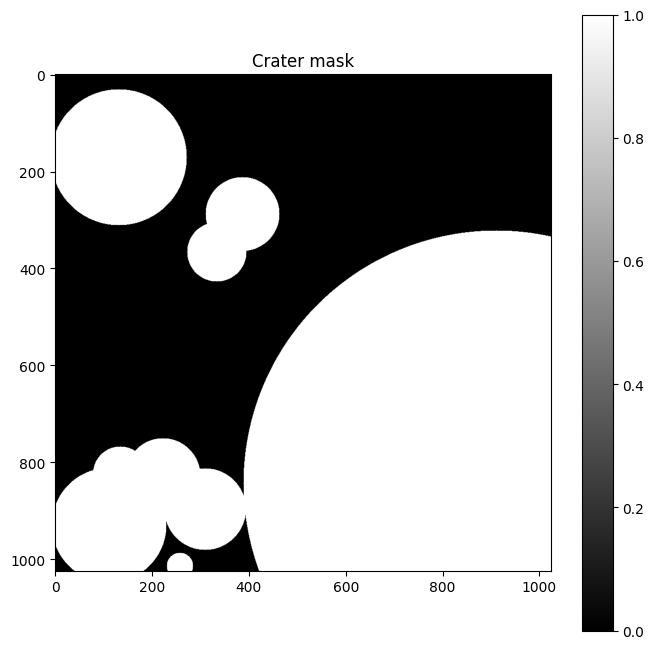

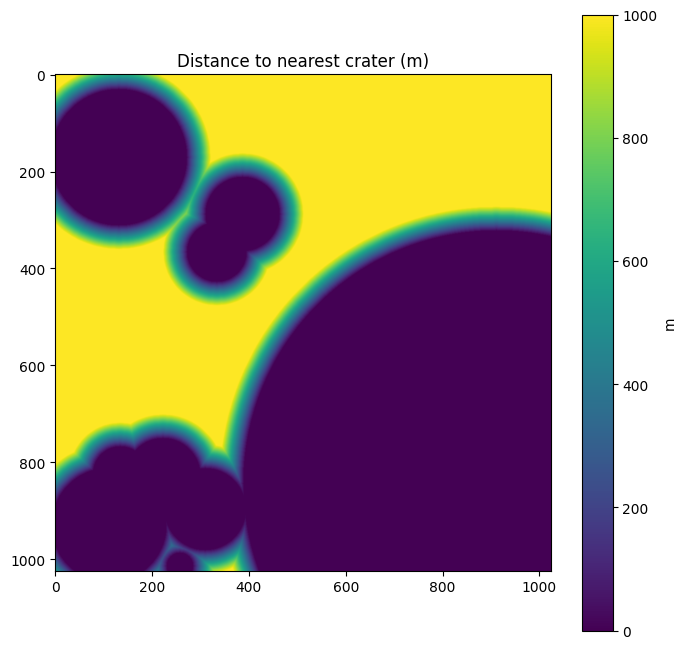

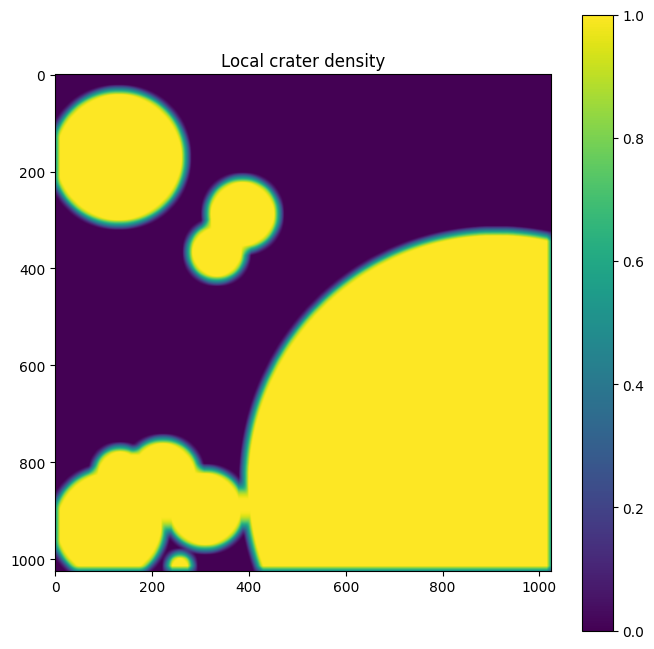

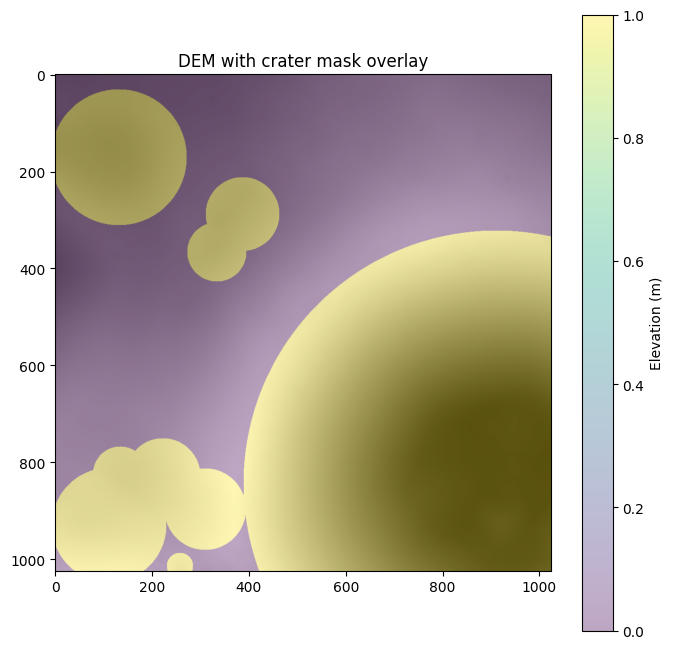

In [18]:
# - Visual inspection is useful here before hazard fusion.
# - This confirms crater products are plausible and aligned to the DEM ROI.

plt.figure(figsize=(8, 8))
plt.imshow(crater_mask, cmap="gray", origin="upper")
plt.title("Crater mask")
plt.colorbar()
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(crater_distance_m, origin="upper")
plt.title("Distance to nearest crater (m)")
plt.colorbar(label="m")
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(crater_density, origin="upper")
plt.title("Local crater density")
plt.colorbar()
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(dem_m, origin="upper", cmap="gray")
plt.imshow(crater_mask, origin="upper", alpha=0.35)
plt.title("DEM with crater mask overlay")
plt.colorbar(label="Elevation (m)")
plt.show()

## Hazard assesor

In [19]:
# References / notes:
# - Phase-2 hazard model:
#     terrain = slope + roughness
#     crater  = mask + distance-risk + density
# - If crater inputs are missing, the backend still falls back to terrain-only mode.
# - This keeps backward compatibility while making the main pipeline crater-aware.

ha = HazardAssessor(
    # terrain normalisation ceilings
    slope_deg_max=38.37,
    roughness_rms_max=19.956,

    # terrain weights
    w_slope=0.7,
    w_roughness=0.3,

    # crater risk controls
    crater_distance_safe_m=200.0,
    crater_density_max=0.25,

    # crater weights
    w_crater_mask=0.4,
    w_crater_distance=0.4,
    w_crater_density=0.2,

    # group-level weights
    terrain_weight=0.7,
    crater_weight=0.3,

    # safety rule
    use_impassable_mask=True,
    impassable_slope_deg=40.0,
)

haz_out = ha.assess(
    slope_deg=slope,
    roughness_rms=rough,
    dem_m=dem_m,
    crater_mask=crater_mask,
    crater_distance_m=crater_distance_m,
    crater_density=crater_density,
)

hazard = haz_out["hazard"]
hazard_meta = haz_out["meta"]
hazard_components = haz_out["components"]

print("Hazard model:", hazard_meta["model"])
print("Hazard stats:", hazard_meta["stats"])
print("Hazard shape:", hazard.shape)

Hazard model: terrain_crater_weighted_v2
Hazard stats: {'hazard_min': 0.0054159993305802345, 'hazard_max': 1.0, 'hazard_mean': 0.47822239995002747, 'nan_ratio': 0.0, 'terrain_mean': 0.4528537690639496, 'crater_mean': 0.5374160408973694}
Hazard shape: (1024, 1024)


### hazard visualissation

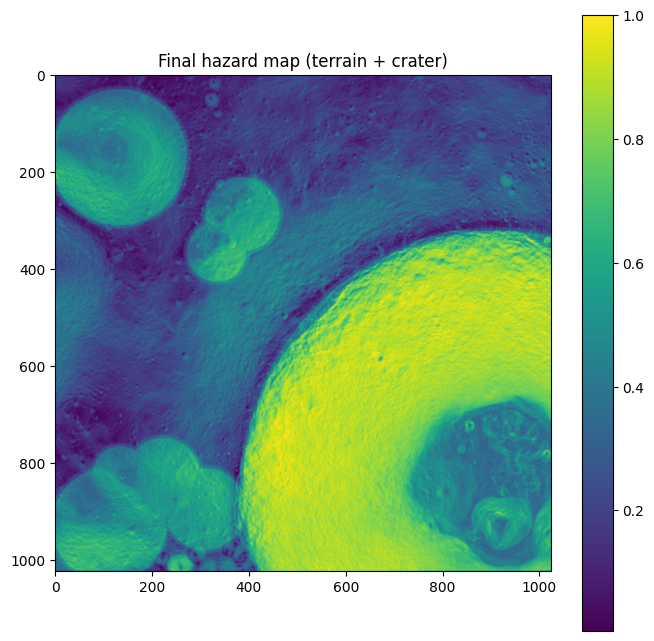

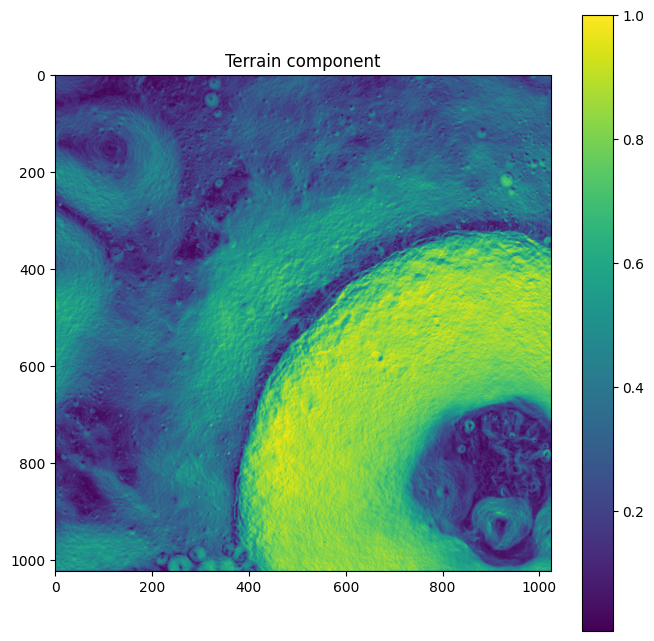

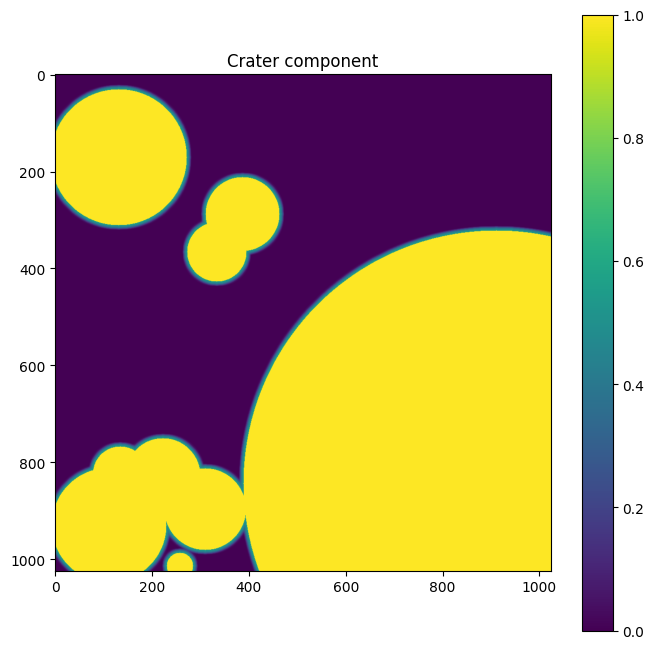

In [20]:
# References / notes:
# - Helpful to inspect the final fused hazard and some internal components.
# - Keep this lightweight so the notebook stays readable.

plt.figure(figsize=(8, 8))
plt.imshow(hazard, origin="upper")
plt.title("Final hazard map (terrain + crater)")
plt.colorbar()
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(hazard_components["terrain_component"], origin="upper")
plt.title("Terrain component")
plt.colorbar()
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(hazard_components["crater_component"], origin="upper")
plt.title("Crater component")
plt.colorbar()
plt.show()

## Build Traversal cost

In [21]:
# new version
# - build_cost_from_hazard() converts hazard in [0,1] into traversal cost:
#       cost = 1 + alpha * hazard
# - Cells with hazard >= hazard_block are treated as blocked via block_cost.
# - This cell uses the final fused Phase-2 hazard produced by HazardAssessor.

# use the exact final hazard that came out of the assessor
hazard_safe = np.asarray(hazard, dtype=np.float32)

# Basic sanity checks before cost building
print("Hazard shape:", hazard_safe.shape)
print("Hazard dtype:", hazard_safe.dtype)
print("Hazard min / max / mean:",
      float(np.nanmin(hazard_safe)),
      float(np.nanmax(hazard_safe)),
      float(np.nanmean(hazard_safe)))
print("Hazard NaN ratio:", float(np.isnan(hazard_safe).mean()))

assert hazard_safe.ndim == 2, "hazard must be a 2D raster"
assert hazard_safe.shape == dem_m.shape, "hazard shape must match DEM shape"
assert not np.isnan(hazard_safe).any(), "hazard contains NaNs; fix before cost building"

# ---- cost model parameters ----
alpha = 10.0
hazard_block = 0.95
block_cost = 1e6

cost = build_cost_from_hazard(
    hazard_safe,
    alpha=alpha,
    hazard_block=hazard_block,
    block_cost=block_cost,
)

print("Cost shape:", cost.shape)
print("Cost dtype:", cost.dtype)
print("Cost min / max / mean:",
      float(np.min(cost)),
      float(np.max(cost)),
      float(np.mean(cost)))
print("Blocked fraction:", float(np.mean(hazard_safe >= hazard_block)))

Hazard shape: (1024, 1024)
Hazard dtype: float32
Hazard min / max / mean: 0.0054159993305802345 1.0 0.47822239995002747
Hazard NaN ratio: 0.0
Cost shape: (1024, 1024)
Cost dtype: float32
Cost min / max / mean: 1.0541599988937378 1000000.0 5590.4404296875
Blocked fraction: 0.005584716796875


## Corridor pathfinding

In [24]:
# new version
# - Pathfinder uses Weighted A* over the cost raster.
# - Corridor search tries progressively wider masks until a path is found.
# - Passing hazard=hazard_safe lets the corridor experiment record path hazard stats

# planner settings
pf = Pathfinder(
    connectivity=8,
    block_cost=block_cost,
    heuristic_weight=1.2,
)

# Example start / goal
start = (569,899)
goal = (122,588)

corridor_radii = [25, 50, 80, 120, 180, 260, 400]

print("Start:", start)
print("Goal:", goal)
print("Connectivity:", pf.connectivity)
print("Heuristic weight:", pf.heuristic_weight)
print("Corridor radii:", corridor_radii)

# Quick start/goal safety check before planning
print("Start hazard / cost:", float(hazard_safe[start]), float(cost[start]))
print("Goal hazard / cost:", float(hazard_safe[goal]), float(cost[goal]))

corr = pf.find_path_corridor(
    cost=cost,
    start=start,
    goal=goal,
    corridor_radii=corridor_radii,
    hazard=hazard_safe,
)

best = corr.get("best", None)
best_radius_px = corr.get("best_radius_px", None)
corridor_experiment = corr.get("experiment", [])

success = bool(best is not None and best.get("success", False))

if success:
    path_rc = np.asarray(best["path_rc"], dtype=np.int32)
    print("Path found.")
    print("Best corridor radius (px):", best_radius_px)
    print("Path nodes:", int(path_rc.shape[0]))
    print("Total planner cost:", float(best["total_cost"]))
    print("Planner meta:", best.get("meta", {}))
else:
    path_rc = np.zeros((0, 2), dtype=np.int32)
    print("No path found in any corridor.")
    if corridor_experiment:
        print("Last corridor attempt:", corridor_experiment[-1])

print("\nCorridor experiment log:")
for row in corridor_experiment:
    print(row)

Start: (569, 899)
Goal: (122, 588)
Connectivity: 8
Heuristic weight: 1.2
Corridor radii: [25, 50, 80, 120, 180, 260, 400]
Start hazard / cost: 0.8917851448059082 9.917851448059082
Goal hazard / cost: 0.20954068005084991 3.0954067707061768
Path found.
Best corridor radius (px): 25
Path nodes: 448
Total planner cost: 3708.49365234375
Planner meta: {'expansions': 27573, 'connectivity': 8, 'heuristic_weight': 1.2}

Corridor experiment log:
{'corridor_radius_px': 25, 'success': True, 'expansions': 27573, 'path_len': 448, 'total_cost': 3708.49365234375, 'path_hazard_mean': 0.5569792985916138, 'path_hazard_max': 0.9415337443351746}


### visual debug

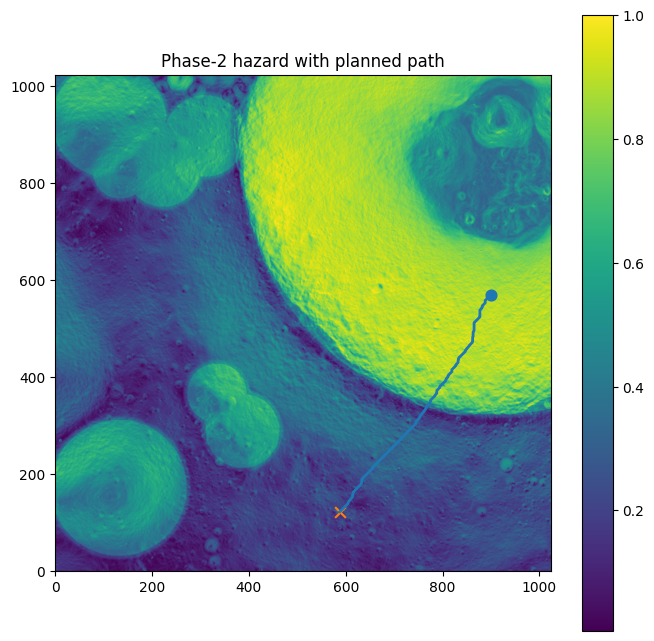

In [27]:
# - Quick diagnostic plot to verify cost blocking and path placement.

plt.figure(figsize=(8, 8))
plt.imshow(hazard_safe, origin="lower")
plt.title("Phase-2 hazard with planned path")
plt.colorbar()

if path_rc.shape[0] > 0:
    plt.plot(path_rc[:, 1], path_rc[:, 0], linewidth=2)

plt.scatter(start[1], start[0], marker="o", s=60)
plt.scatter(goal[1], goal[0], marker="x", s=60)
plt.show()

## visualise

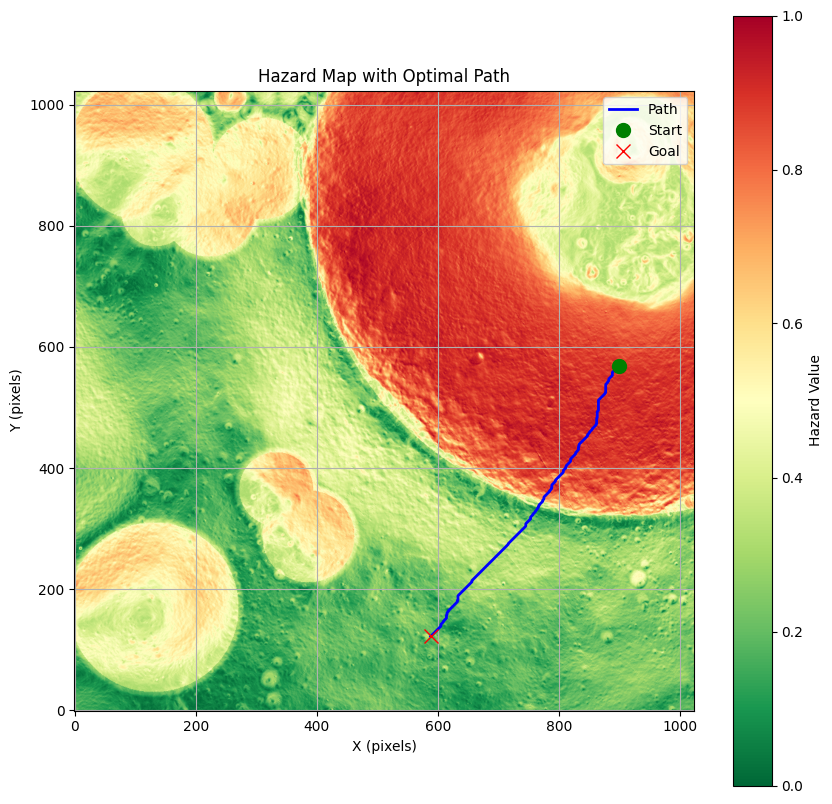

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
plt.imshow(hazard_safe, cmap="RdYlGn_r", origin='lower', vmin=0, vmax=1)
plt.colorbar(label='Hazard Value')
plt.title('Hazard Map with Optimal Path')

# Plot the path
if path_rc.shape[0] > 0:
    plt.plot(path_rc[:, 1], path_rc[:, 0], color='blue', linewidth=2, label='Path')

# Plot start and goal points
plt.plot(start[1], start[0], 'go', markersize=10, label='Start') # green circle
plt.plot(goal[1], goal[0], 'rx', markersize=10, label='Goal')   # red x

plt.xlabel('X (pixels)')
plt.ylabel('Y (pixels)')
plt.legend()
plt.grid(True)
plt.show()

## save nav run

In [28]:
# References / notes:
# - save_navigation() writes hazard.npy, cost.npy, path_rc.npy, nav_meta.json
#   under the derived ROI navigation folder.
# - Evaluator reads this saved-run structure directly.
# - Keep the saved hazard raster consistent with the one used to build the cost grid.

success = bool(best is not None and best.get("success", False))

nav_meta = {
    "start_rc": list(start),
    "goal_rc": list(goal),
    "hazard_assessor": hazard_meta,
    "cost_model": {
        "alpha": float(alpha),
        "hazard_block": float(hazard_block),
        "block_cost": float(block_cost),
    },
    "pathfinder": {
        "connectivity": int(pf.connectivity),
        "heuristic_weight": float(pf.heuristic_weight),
        "corridor_radii": list(map(int, corridor_radii)),
        "corridor_radius_px_used": int(best_radius_px) if best_radius_px is not None else None,
    },
    "result": {
        "success": success,
        "total_cost": float(best["total_cost"]) if success else None,
        "path_len": int(path_rc.shape[0]),
        "expansions": int((best.get("meta") or {}).get("expansions", -1)) if best is not None else -1,
        "failure_reason": None if success else "no_path_found_in_any_corridor",
    },
    "run_info": {
        "hazard_model_id": hazard_meta.get("model"),
    },
    "corridor_experiment": corridor_experiment,
}

run_dir = dh.save_navigation(
    tile_id=TILE_ID,
    roi=CANONICAL_ROI_PIXELS,
    hazard=hazard,
    cost=cost,
    path_rc=path_rc,
    nav_meta=nav_meta,
    run_name="GEOTIFF_navigation_phase2_terrain_crater_v3",
)

print("Saved navigation run to:", run_dir)

Saved navigation run to: /content/drive/MyDrive/Endymion/persistent/derived/ldem_80s_20m/roi_14688_15712_14688_15712/navigation/GEOTIFF_navigation_phase2_terrain_crater_v3


## Evaluate run

In [ ]:
# References / notes:
# - Evaluator loads hazard.npy, cost.npy, path_rc.npy and nav_meta.json from run_dir.
# - save() writes metrics.json next to the saved navigation outputs.

ev = Evaluator(run_dir, pixel_size_m=PIXEL_SIZE_M)
metrics = ev.evaluate()
metrics_path = ev.save("metrics.json")

print("Metrics saved to:", metrics_path)

print("\nRun:")
print(metrics["run"])

print("\nStatus:")
print(metrics["status"])

print("\nGeometry:")
print(metrics["geometry"])

print("\nSafety:")
print(metrics["safety"])

print("\nEfficiency:")
print(metrics["efficiency"])

# summary
print("\nSummary:")
print(
    f"Success={metrics['status']['success']}, "
    f"path_length_m={metrics['geometry']['path_length_m']}, "
    f"mean_hazard={metrics['safety']['path_hazard_mean']}, "
    f"cost_per_m={metrics['efficiency']['cost_per_m']}, "
    f"expansions={metrics['efficiency']['expansions']}"
)

Metrics saved to: /content/drive/MyDrive/Endymion/persistent/derived/ldem_80s_20m/roi_14688_15712_14688_15712/navigation/GEOTIFF_navigation_phase2_terrain_crater_v2/metrics.json

Run:
{'run_name': 'GEOTIFF_navigation_phase2_terrain_crater_v2', 'tile_id': 'ldem_80s_20m', 'roi': [14688, 15712, 14688, 15712]}

Status:
{'success': True, 'failure_reason': None}

Geometry:
{'path_nodes': 826, 'path_length_m': 17378.132752230962, 'straight_line_m': 16606.757660663323, 'detour_ratio': 1.0464494699886424, 'turn_count': 98, 'turns_per_m': 0.00563927099632836}

Safety:
{'path_hazard_mean': 0.24771805809580746, 'path_hazard_max': 0.635172963142395, 'path_hazard_p95': 0.5395137518644333, 'haz_per_m': 0.011774286622414538, 'frac_hazard_ge_block': 0.0, 'hazard_mean_ratio': 0.5179976055527578, 'safety_score': 0.9883627338843325}

Efficiency:
{'cost_sum_along_path': 2872.1511603593826, 'cost_per_m': 0.16527386464985214, 'planner_total_cost': 3000.172119140625, 'expansions': 41636}

Summary:
Success=Tru

## Hazard assessor — terrain-only baseline

In [ ]:
# References / notes:
# - Terrain-only baseline using the same HazardAssessor class.
# - No crater inputs provided → falls back to Phase-1 behaviour.
# - Everything else (cost, planner, evaluator) remains identical.

ha_baseline = HazardAssessor(
    slope_deg_max=38.37,
    roughness_rms_max=19.956,
    w_slope=0.7,
    w_roughness=0.3,
    terrain_weight=1.0,   # full terrain influence
    crater_weight=0.0,    # explicitly disable crater group
    use_impassable_mask=True,
    impassable_slope_deg=40.0,
)

haz_out_base = ha_baseline.assess(
    slope_deg=slope,
    roughness_rms=rough,
    dem_m=dem_m,
    # no crater inputs
)

hazard_base = haz_out_base["hazard"]
hazard_meta_base = haz_out_base["meta"]

print("Baseline hazard model:", hazard_meta_base["model"])
print("Baseline hazard stats:", hazard_meta_base["stats"])

## Bechmark

In [ ]:
# References / notes:
# - BenchmarkRunner assumes derived rasters already exist.
# - Keep this as a separate optional section, not part of the main path.

from src.evaluation.benchmark_runner import BenchmarkRunner, BenchmarkConfig

cfg = BenchmarkConfig(
    tile_id=TILE_ID,
    roi=CANONICAL_ROI_PIXELS,
    benchmark_id="GEOTIFF_benchmark_v3", # remember to change for each  different run
    pixel_size_m=PIXEL_SIZE_M,
)

br = BenchmarkRunner(dh, cfg)

# Example:
# results = br.run_benchmark_file("/content/Endymion/benchmarks/benchmark_v1.json")
# print(results)


## crater predictor (OLD) - Dont run

In [ ]:
# References / notes:
# - Goal: validate predictor output shape, cache behaviour, and visual plausibility
#   before starting real ML training.

import numpy as np
import matplotlib.pyplot as plt

from src.models.crater_predictor import CraterPredictor
from src.data.crater_raster import build_crater_mask_from_catalogue, CraterRasterConfig

ROBBINS_CSV_PATH = "/content/Endymion/data/lunar_crater_database_robbins_2018.csv"

tile_spec = dh.tiles[TILE_ID]
dem_img_path = dh.runtime_dir / tile_spec.tif_filename

print("DEM path:", dem_img_path)
print("Robbins CSV path:", ROBBINS_CSV_PATH)
print("ROI:", CANONICAL_ROI_PIXELS)
print("Feature keys:", list(features.keys()))

DEM path: /content/Endymion_runtime/LDEM_80S_20MPP_ADJ.TIF
Robbins CSV path: /content/Endymion/data/lunar_crater_database_robbins_2018.csv
ROI: (14688, 15712, 14688, 15712)
Feature keys: ['slope_deg', 'slope_rise_run', 'roughness_rms']


In [ ]:
# ---- Test 1: stub predictor ----
cp_stub = CraterPredictor(model_id="stub_v1")

stub_out = cp_stub.predict_proba_map(
    features=features,
    dem_m=dem_m,
    tile_id=TILE_ID,
    roi_pixels=CANONICAL_ROI_PIXELS,
    dh=dh,
)

stub_map = stub_out["crater_proba"]
stub_meta = stub_out["meta"]

print("Stub meta:", stub_meta)
print("Stub shape:", stub_map.shape)
print("Stub min/max:", float(np.nanmin(stub_map)), float(np.nanmax(stub_map)))

assert stub_map.shape == dem_m.shape, "Stub crater map shape does not match DEM shape"
assert np.all(stub_map == 0), "Stub predictor should return all zeros"

Stub meta: {'model_id': 'stub_v1', 'note': 'Phase-1 stub: returns zero crater outputs.'}
Stub shape: (1024, 1024)
Stub min/max: 0.0 0.0


In [ ]:
print("ROI:", CANONICAL_ROI_PIXELS)
print("type:", type(CANONICAL_ROI_PIXELS))
print("dem_img_path exists:", Path(dem_img_path).exists())
print("csv exists:", Path(ROBBINS_CSV_PATH).exists())

ROI: (14688, 15712, 14688, 15712)
type: <class 'tuple'>
dem_img_path exists: True
csv exists: True


ROI  SHOULDNT BE A TYPING CLASS

In [ ]:
'''
from src.data.data_handler import CANONICAL_ROI

ROI_PIXELS = CANONICAL_ROI

assert isinstance(ROI_PIXELS, tuple), f"Expected tuple, got {type(ROI_PIXELS)}"
assert len(ROI_PIXELS) == 4, f"Expected 4 values, got {ROI_PIXELS}"
assert all(isinstance(x, int) for x in ROI_PIXELS), f"ROI values must be ints: {ROI_PIXELS}"

print("ROI_PIXELS:", ROI_PIXELS)
'''

In [ ]:
# References / notes:
# - Notebook-side normalisation for ROI type consistency.
# - Keeps crater testing robust even if ROI was reloaded from JSON as a list.

ROI_PIXELS = CANONICAL_ROI_PIXELS

assert len(ROI_PIXELS) == 4, f"Expected 4 values, got {ROI_PIXELS}"
assert all(isinstance(x, int) for x in ROI_PIXELS), f"ROI values must be ints: {ROI_PIXELS}"

print("ROI_PIXELS:", ROI_PIXELS)
print("ROI_PIXELS type:", type(ROI_PIXELS))

ROI_PIXELS: (14688, 15712, 14688, 15712)
ROI_PIXELS type: <class 'tuple'>


In [ ]:
print("ROI value:", CANONICAL_ROI_PIXELS)
print("ROI type:", type(CANONICAL_ROI_PIXELS))

ROI value: (14688, 15712, 14688, 15712)
ROI type: <class 'tuple'>


In [ ]:
import pandas as pd

print("CSV path:", ROBBINS_CSV_PATH)

df_check = pd.read_csv(ROBBINS_CSV_PATH, nrows=3)
print("Columns as read:")
print(df_check.columns.tolist())

CSV path: /content/Endymion/data/lunar_crater_database_robbins_2018.csv
Columns as read:
['CRATER_ID', 'LAT_CIRC_IMG', 'LON_CIRC_IMG', 'LAT_ELLI_IMG', 'LON_ELLI_IMG', 'DIAM_CIRC_IMG', 'DIAM_CIRC_SD_IMG', 'DIAM_ELLI_MAJOR_IMG', 'DIAM_ELLI_MINOR_IMG', 'DIAM_ELLI_ECCEN_IMG', 'DIAM_ELLI_ELLIP_IMG', 'DIAM_ELLI_ANGLE_IMG', 'LAT_ELLI_SD_IMG', 'LON_ELLI_SD_IMG', 'DIAM_ELLI_MAJOR_SD_IMG', 'DIAM_ELLI_MINOR_SD_IMG', 'DIAM_ELLI_ANGLE_SD_IMG', 'DIAM_ELLI_ECCEN_SD_IMG', 'DIAM_ELLI_ELLIP_SD_IMG', 'ARC_IMG', 'PTS_RIM_IMG']


In [ ]:
import pandas as pd

print("CSV path:", ROBBINS_CSV_PATH)

for sep in [",", ";", "\t", "|"]:
    try:
        df_try = pd.read_csv(ROBBINS_CSV_PATH, sep=sep, nrows=2)
        print(f"\nsep={repr(sep)}")
        print("ncols:", len(df_try.columns))
        print("columns sample:", df_try.columns.tolist()[:10])
    except Exception as e:
        print(f"\nsep={repr(sep)} failed:", e)

CSV path: /content/Endymion/data/lunar_crater_database_robbins_2018.csv

sep=','
ncols: 21
columns sample: ['CRATER_ID', 'LAT_CIRC_IMG', 'LON_CIRC_IMG', 'LAT_ELLI_IMG', 'LON_ELLI_IMG', 'DIAM_CIRC_IMG', 'DIAM_CIRC_SD_IMG', 'DIAM_ELLI_MAJOR_IMG', 'DIAM_ELLI_MINOR_IMG', 'DIAM_ELLI_ECCEN_IMG']

sep=';'
ncols: 1
columns sample: ['CRATER_ID,LAT_CIRC_IMG,LON_CIRC_IMG,LAT_ELLI_IMG,LON_ELLI_IMG,DIAM_CIRC_IMG,DIAM_CIRC_SD_IMG,DIAM_ELLI_MAJOR_IMG,DIAM_ELLI_MINOR_IMG,DIAM_ELLI_ECCEN_IMG,DIAM_ELLI_ELLIP_IMG,DIAM_ELLI_ANGLE_IMG,LAT_ELLI_SD_IMG,LON_ELLI_SD_IMG,DIAM_ELLI_MAJOR_SD_IMG,DIAM_ELLI_MINOR_SD_IMG,DIAM_ELLI_ANGLE_SD_IMG,DIAM_ELLI_ECCEN_SD_IMG,DIAM_ELLI_ELLIP_SD_IMG,ARC_IMG,PTS_RIM_IMG']

sep='\t'
ncols: 1
columns sample: ['CRATER_ID,LAT_CIRC_IMG,LON_CIRC_IMG,LAT_ELLI_IMG,LON_ELLI_IMG,DIAM_CIRC_IMG,DIAM_CIRC_SD_IMG,DIAM_ELLI_MAJOR_IMG,DIAM_ELLI_MINOR_IMG,DIAM_ELLI_ECCEN_IMG,DIAM_ELLI_ELLIP_IMG,DIAM_ELLI_ANGLE_IMG,LAT_ELLI_SD_IMG,LON_ELLI_SD_IMG,DIAM_ELLI_MAJOR_SD_IMG,DIAM_ELLI_MINOR_SD_IMG,DIA

In [ ]:
with open(ROBBINS_CSV_PATH, "r", encoding="utf-8", errors="ignore") as f:
    for i in range(5):
        print(f"Line {i+1}:", f.readline().rstrip())

Line 1: CRATER_ID,LAT_CIRC_IMG,LON_CIRC_IMG,LAT_ELLI_IMG,LON_ELLI_IMG,DIAM_CIRC_IMG,DIAM_CIRC_SD_IMG,DIAM_ELLI_MAJOR_IMG,DIAM_ELLI_MINOR_IMG,DIAM_ELLI_ECCEN_IMG,DIAM_ELLI_ELLIP_IMG,DIAM_ELLI_ANGLE_IMG,LAT_ELLI_SD_IMG,LON_ELLI_SD_IMG,DIAM_ELLI_MAJOR_SD_IMG,DIAM_ELLI_MINOR_SD_IMG,DIAM_ELLI_ANGLE_SD_IMG,DIAM_ELLI_ECCEN_SD_IMG,DIAM_ELLI_ELLIP_SD_IMG,ARC_IMG,PTS_RIM_IMG
Line 2: 00-1-000000,-19.8304,264.757,-19.8905,264.665,940.96,21.3179,975.874,905.968,0.371666,1.07716,35.9919,0.00788792,0.00842373,0.63675,0.560417,0.373749,0.00208495,0.000968482,0.568712,8088
Line 3: 00-1-000001,44.7763,328.602,44.4083,329.046,249.84,5.99621,289.44,245.786,0.528111,1.17761,127.003,0.0111776,0.0151013,1.05278,0.209035,0.357296,0.00510045,0.00439887,0.627328,2785
Line 4: 00-1-000002,57.0866,82.0995,56.9,81.6464,599.778,21.579,632.571,561.435,0.460721,1.1267,149.162,0.0084645,0.0195153,0.776149,0.747352,0.374057,0.00309534,0.00203974,0.492373,5199
Line 5: 00-1-000003,1.96124,230.622,1.95072,230.588,558.762,1

In [ ]:
import pandas as pd

df_no_header = pd.read_csv(ROBBINS_CSV_PATH, header=None)
print("Shape:", df_no_header.shape)
print(df_no_header.head())

/tmp/ipykernel_1082/3055983093.py:3: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df_no_header = pd.read_csv(ROBBINS_CSV_PATH, header=None)


Shape: (1296797, 21)
            0             1             2             3             4   \
0    CRATER_ID  LAT_CIRC_IMG  LON_CIRC_IMG  LAT_ELLI_IMG  LON_ELLI_IMG   
1  00-1-000000      -19.8304       264.757      -19.8905       264.665   
2  00-1-000001       44.7763       328.602       44.4083       329.046   
3  00-1-000002       57.0866       82.0995          56.9       81.6464   
4  00-1-000003       1.96124       230.622       1.95072       230.588   

              5                 6                    7                    8   \
0  DIAM_CIRC_IMG  DIAM_CIRC_SD_IMG  DIAM_ELLI_MAJOR_IMG  DIAM_ELLI_MINOR_IMG   
1         940.96           21.3179              975.874              905.968   
2         249.84           5.99621               289.44              245.786   
3        599.778            21.579              632.571              561.435   
4        558.762           14.1819              568.529              546.378   

                    9   ...                   11     

In [ ]:
import pandas as pd

robbins_columns = [
    "CRATER_ID",
    "LAT_CIRC_IMG",
    "LON_CIRC_IMG",
    "LAT_ELLI_IMG",
    "LON_ELLI_IMG",
    "DIAM_CIRC_IMG",
    "DIAM_CIRC_SD_IMG",
    "DIAM_ELLI_MAJOR_IMG",
    "DIAM_ELLI_MINOR_IMG",
    "DIAM_ELLI_ECCEN_IMG",
    "DIAM_ELLI_ELLIP_IMG",
    "DIAM_ELLI_ANGLE_IMG",
    "LAT_ELLI_SD_IMG",
    "LON_ELLI_SD_IMG",
    "DIAM_ELLI_MAJOR_SD_IMG",
    "DIAM_ELLI_MINOR_SD_IMG",
    "DIAM_ELLI_ANGLE_SD_IMG",
    "DIAM_ELLI_ECCEN_SD_IMG",
    "DIAM_ELLI_ELLIP_SD_IMG",
    "ARC_IMG",
    "PTS_RIM_IMG",
]

df_check = pd.read_csv(
    ROBBINS_CSV_PATH,
    header=None,
    names=robbins_columns,
    skiprows=1,
    encoding="utf-8-sig",
)

print(df_check.head())
print(df_check.columns.tolist())
print(df_check.shape)

     CRATER_ID  LAT_CIRC_IMG  LON_CIRC_IMG  LAT_ELLI_IMG  LON_ELLI_IMG  \
0  03-1-004085     -0.988655       253.816     -0.988689       253.816   
1  03-1-004086     -1.059790       253.756     -1.059780       253.757   
2  03-1-004087     -0.011252       253.767     -0.011372       253.767   
3  03-1-004089     -0.601537       253.791     -0.601458       253.791   
4  03-1-004090     -0.702737       253.795     -0.702712       253.795   

   DIAM_CIRC_IMG  DIAM_CIRC_SD_IMG  DIAM_ELLI_MAJOR_IMG  DIAM_ELLI_MINOR_IMG  \
0        2.92969          0.055351              3.05529              2.78933   
1        1.34166          0.028771              1.36381              1.31433   
2        1.78981          0.033968              1.86102              1.71801   
3        1.85078          0.039258              1.92484              1.76025   
4        1.36115          0.023376              1.39118              1.33176   

   DIAM_ELLI_ECCEN_IMG  ...  DIAM_ELLI_ANGLE_IMG  LAT_ELLI_SD_IMG  \
0    

In [ ]:
import importlib
import src.data.crater_raster as cr_mod
import src.models.crater_predictor as cp_mod

importlib.reload(cr_mod)
importlib.reload(cp_mod)

<module 'src.models.crater_predictor' from '/content/Endymion/src/models/crater_predictor.py'>

In [ ]:
CraterPredictor = cp_mod.CraterPredictor
cp_cat = CraterPredictor(model_id="catalogue_raster_v1")

In [ ]:
# ---- Test 2: catalogue-backed crater raster ----
cp_cat = CraterPredictor(model_id="catalogue_raster_v1")

cat_out = cp_cat.predict_proba_map(
    features=features,
    dem_m=dem_m,
    tile_id=TILE_ID,
    roi_pixels=CANONICAL_ROI_PIXELS,
    dh=dh,
    dem_img_path=dem_img_path,
    robbins_csv_path=ROBBINS_CSV_PATH,
    rebuild_if_missing=True,
)

crater_map = cat_out["crater_proba"]
crater_meta = cat_out["meta"]

print("Catalogue meta:", crater_meta)
print("Crater map shape:", crater_map.shape)
print("Unique values:", np.unique(crater_map))
print("Crater coverage ratio:", float(np.mean(crater_map > 0)))

assert crater_map.shape == dem_m.shape, "Catalogue crater map shape does not match DEM shape"
assert crater_map.dtype in (np.float32, np.float64, np.uint8), "Unexpected crater map dtype"

Catalogue meta: {'model_id': 'catalogue_raster_v1', 'source': 'built_from_catalogue', 'saved_to': '/content/drive/MyDrive/Endymion/persistent/derived/ldem_80s_20m/roi_14688_15712_14688_15712', 'products': {'crater_mask': 'crater_mask.npy', 'crater_distance_m': 'crater_mask_distance.npy', 'crater_density': 'crater_mask_density.npy'}, 'catalogue': {'roi_pixels': {'row_start': 14688, 'row_end': 15712, 'col_start': 14688, 'col_end': 15712}, 'roi_shape': {'height': 1024, 'width': 1024}, 'pixel_size_m': 20.0, 'catalogue_total_rows': 1296796, 'craters_centres_in_roi': 9, 'craters_rasterised': 9, 'products': ['crater_mask', 'crater_distance_m', 'crater_density'], 'stats': {'mask_coverage_ratio': 0.5261030197143555, 'distance_min_m': 0.0, 'distance_max_m': 1000.0, 'distance_mean_m': 397.15966796875, 'density_min': 0.0, 'density_max': 1.0, 'density_mean': 0.5218557119369507}, 'config': {'min_diameter_m': 40.0, 'max_diameter_m': None, 'density_window_px': 21, 'max_distance_m': 1000.0, 'latitude_c

In [ ]:
# ---- Test 3: cached reload ----
cat_out_cached = cp_cat.predict_proba_map(
    features=features,
    dem_m=dem_m,
    tile_id=TILE_ID,
    roi_pixels=CANONICAL_ROI_PIXELS,
    dh=dh,
    rebuild_if_missing=False,
)

crater_map_cached = cat_out_cached["crater_proba"]
cached_meta = cat_out_cached["meta"]

print("Cached meta:", cached_meta)

assert crater_map_cached.shape == crater_map.shape
assert np.array_equal(crater_map_cached, crater_map), "Cached crater map differs from rebuilt map"

Cached meta: {'model_id': 'catalogue_raster_v1', 'source': 'derived_cache', 'products': {'crater_mask': 'crater_mask.npy', 'crater_distance_m': 'crater_mask_distance.npy', 'crater_density': 'crater_mask_density.npy'}, 'catalogue': {'roi_pixels': {'row_start': 14688, 'row_end': 15712, 'col_start': 14688, 'col_end': 15712}, 'roi_shape': {'height': 1024, 'width': 1024}, 'pixel_size_m': 20.0, 'catalogue_total_rows': 1296796, 'craters_centres_in_roi': 9, 'craters_rasterised': 9, 'products': ['crater_mask', 'crater_distance_m', 'crater_density'], 'stats': {'mask_coverage_ratio': 0.5261030197143555, 'distance_min_m': 0.0, 'distance_max_m': 1000.0, 'distance_mean_m': 397.15966796875, 'density_min': 0.0, 'density_max': 1.0, 'density_mean': 0.5218557119369507}, 'config': {'min_diameter_m': 40.0, 'max_diameter_m': None, 'density_window_px': 21, 'max_distance_m': 1000.0, 'latitude_column': 'LAT_CIRC_IMG', 'longitude_column': 'LON_CIRC_IMG', 'diameter_km_column': 'DIAM_CIRC_IMG'}}}


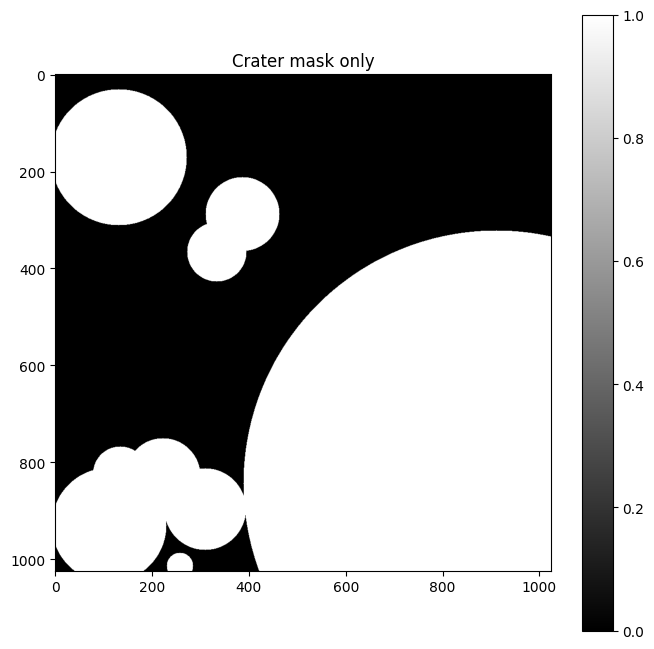

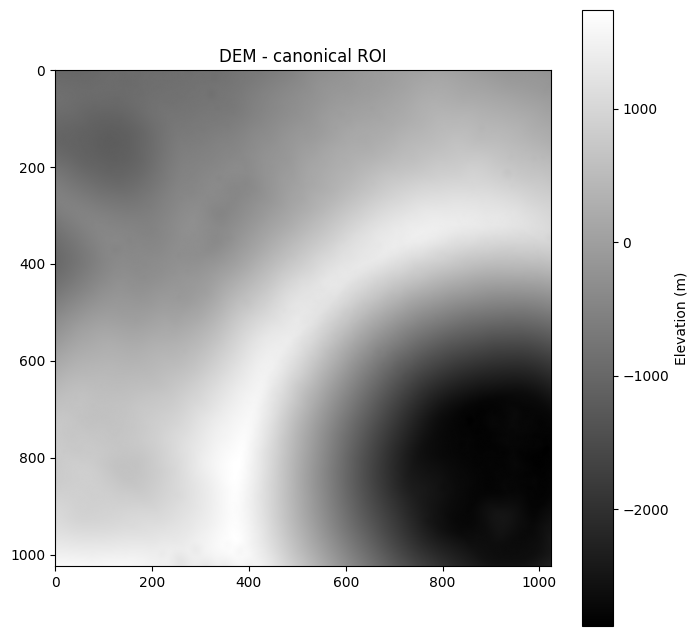

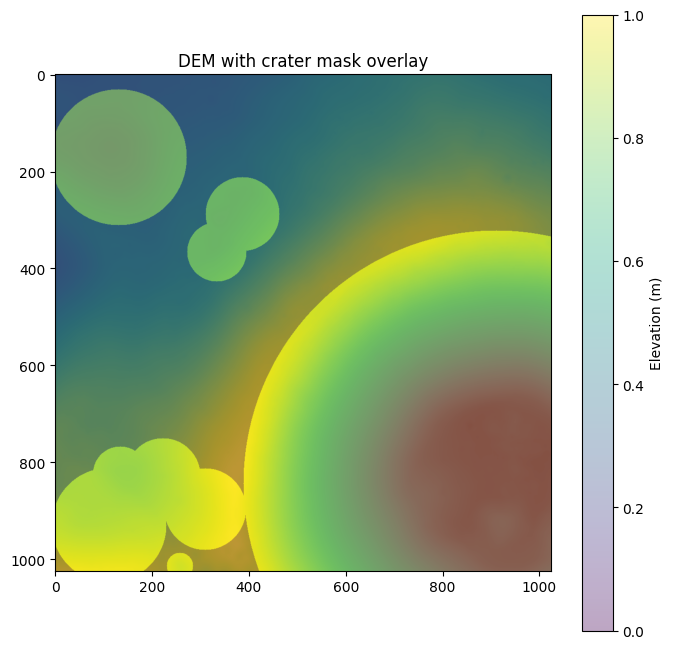

In [ ]:
# ---- Visual inspection ----

plt.figure(figsize=(8, 8))
plt.imshow(crater_map, cmap="gray")
plt.title("Crater mask only")
plt.colorbar()
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(dem_m, origin="upper", cmap="gray" )
plt.title("DEM - canonical ROI")
plt.colorbar(label="Elevation (m)")
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(dem_m, origin="upper")
plt.imshow(crater_map, origin="upper", alpha=0.35)
plt.title("DEM with crater mask overlay")
plt.colorbar(label="Elevation (m)")
plt.show()

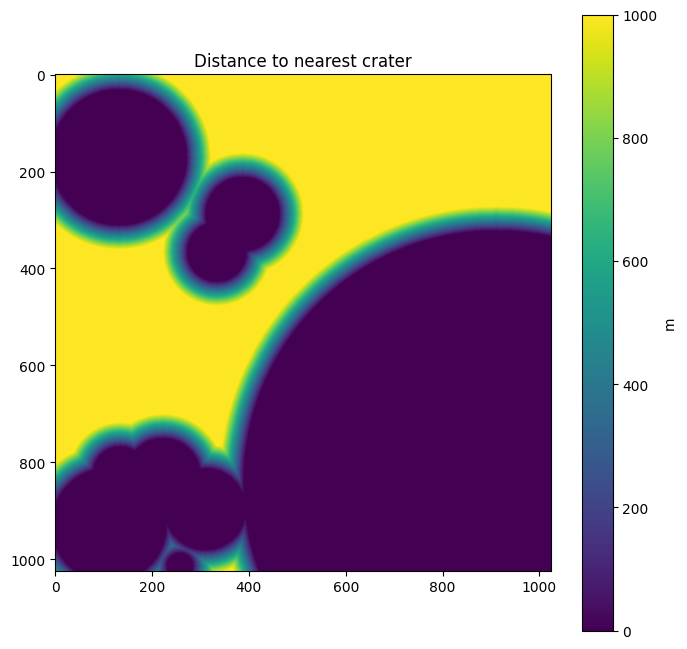

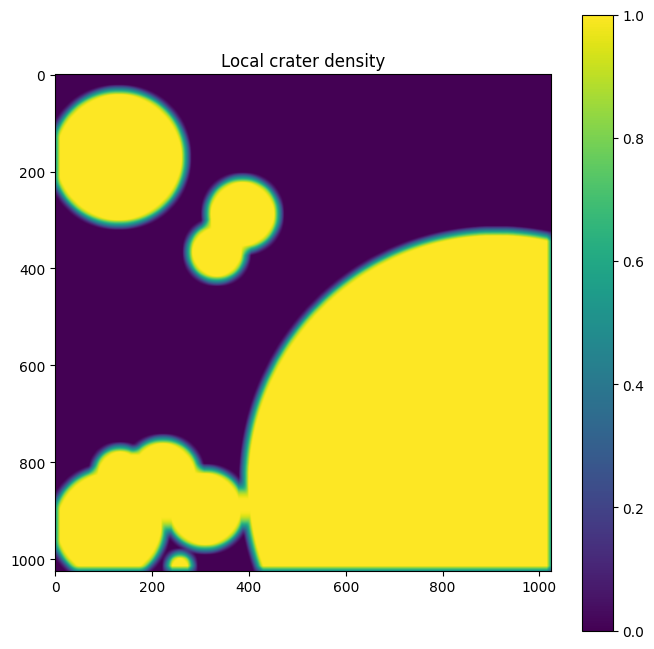

In [ ]:
# visual verification of some other products
# dsitance
plt.figure(figsize=(8, 8))

plt.imshow(cat_out["crater_distance_m"], origin="upper")
plt.title("Distance to nearest crater")
plt.colorbar(label="m")
plt.show()

#density
plt.figure(figsize=(8, 8))

plt.imshow(cat_out["crater_density"], origin="upper")
plt.title("Local crater density")
plt.colorbar()
plt.show()